In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import os

# Load data

In [7]:
path = '/scratch/v14/mac599/Neural_Climate/LUCIE/' 
if os.path.exists(path):
    print("on the server")
else:
    print("on mac")
    path = './'

data_name = 'era5_T30_regridded.npz'  # atmospheric data/

on mac


In [8]:
data = np.load(path + data_name)

In [9]:
print(data)

In [10]:
for key in data.keys():
    print(key, "shape",data[key].shape)

temperature shape (16538, 48, 96)
humidity shape (16538, 48, 96)
u_wind shape (16538, 48, 96)
v_wind shape (16538, 48, 96)
surface_pressure shape (16538, 48, 96)
precipitation shape (16538, 48, 96)
tisr shape (16538, 48, 96)
orography shape (16538, 48, 96)


- 16538/365 ~ 45 years, 1980 regime shift (so the data is relatively stationary)

- precipitation: raindrops
- TISR: total incoming solar radiation (input only, forcing term)
- orography: how air flow is altered by terrain, (input only, forcing term)

## 1. view the range of different variables

In [11]:
data_dict = {'key': [], 'min': [], 'max': [], 'mean': [], 'std': []}
for key in data.keys():
    data_dict['key'].append(key)
    data_dict['min'].append(data[key].min())
    data_dict['max'].append(data[key].max())
    data_dict['mean'].append(data[key].mean())
    data_dict['std'].append(data[key].std())
    
# print(data_dict)
# conver to pandas dataframe
df = pd.DataFrame(data_dict)
print(df)

                key           min           max          mean           std
0       temperature  1.800381e+02  3.370369e+02  2.774627e+02  1.781638e+01
1          humidity -2.013051e-02  4.289661e-02  6.629979e-03  5.532822e-03
2            u_wind -7.898135e+01  1.047542e+02  1.069576e+01  1.556001e+01
3            v_wind -8.832004e+01  9.005918e+01 -2.342493e-02  1.214933e+01
4  surface_pressure  5.223583e+04  1.064829e+05  9.681139e+04  9.123895e+03
5     precipitation -2.081668e-17  1.500982e-01  6.106931e-04  1.604489e-03
6              tisr  0.000000e+00  5.054849e+06  1.079093e+06  1.444145e+06
7         orography -2.387258e+01  5.174925e+03  3.671712e+02  8.092916e+02


- unnormalized data

## 2. view the distribution of the selected variables


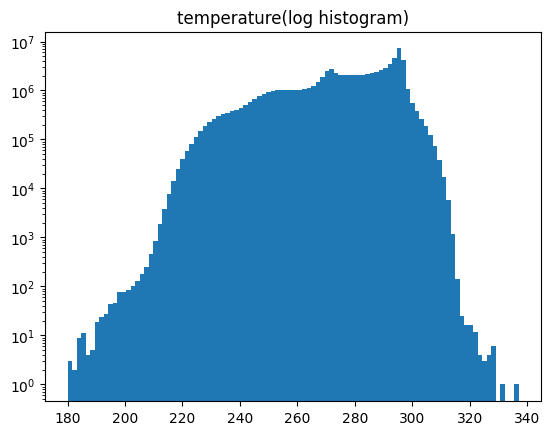

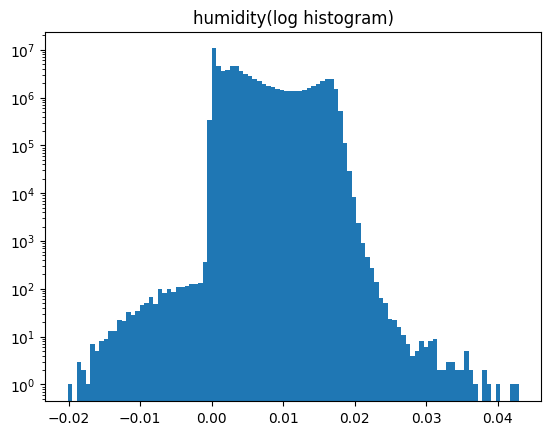

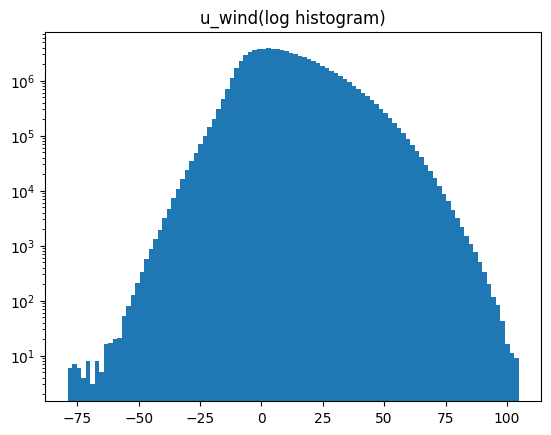

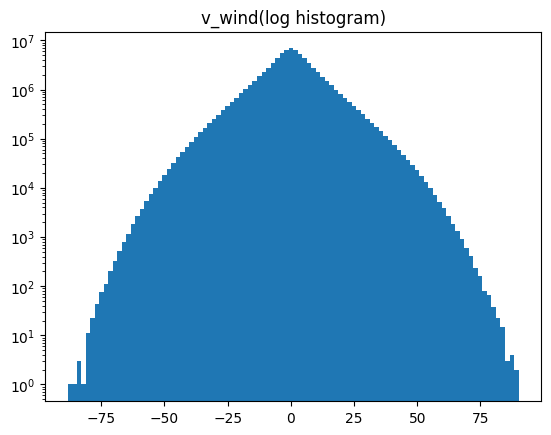

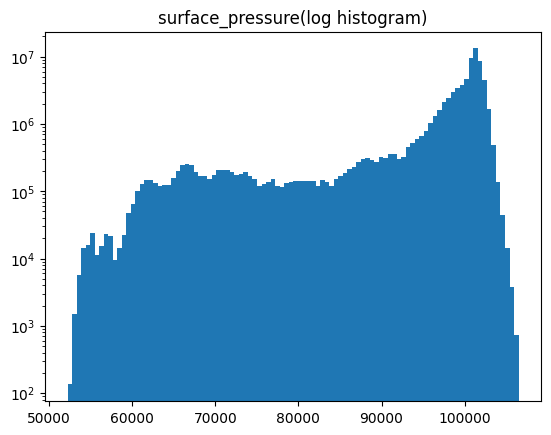

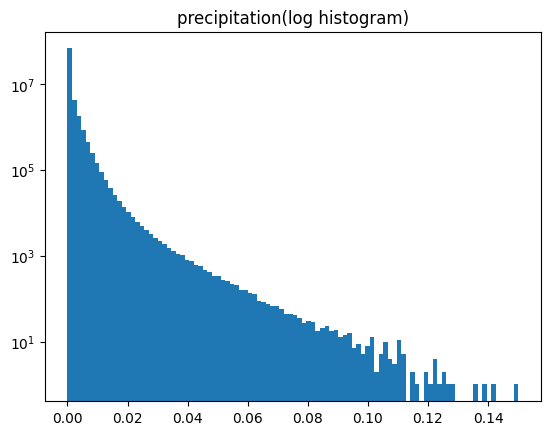

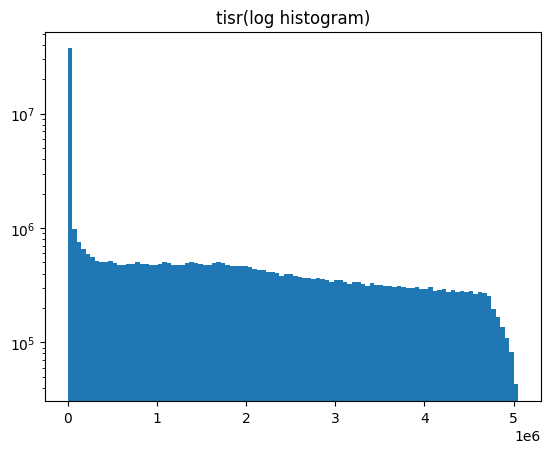

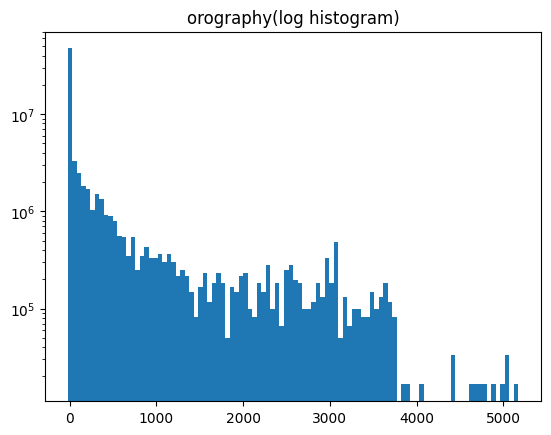

In [12]:
selected_keys = ['temperature', 'humidity', 'u_wind', 'v_wind', 'surface_pressure', 'precipitation', 'tisr', 'orography']
for keys in selected_keys:
    # plot the log histogram
    plt.hist(data[keys].flatten(), bins=100, log=True)
    plt.title(keys + "(log histogram)")
    plt.show()

## 3. (short term) Spatial temporal dynamics at a 7-day interval for one month

starting date: year: 1984


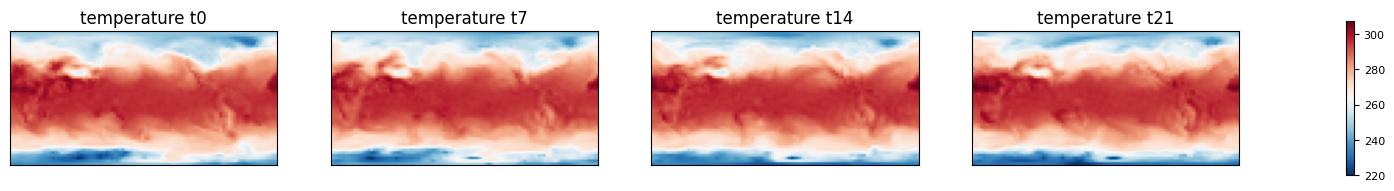

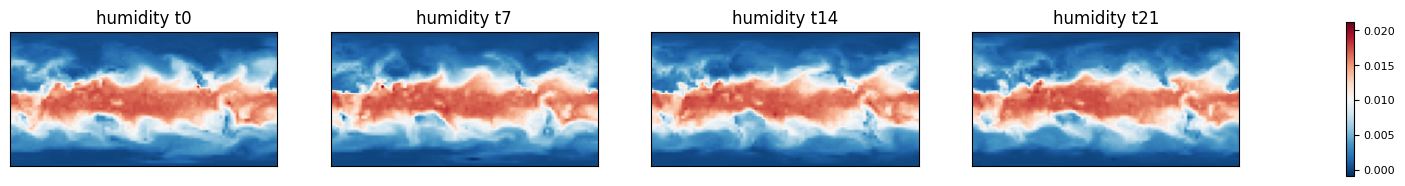

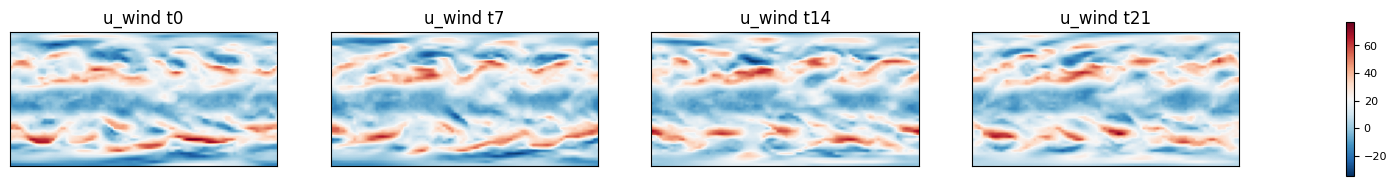

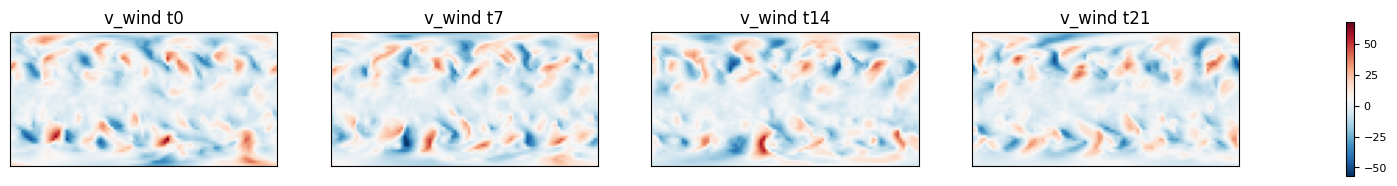

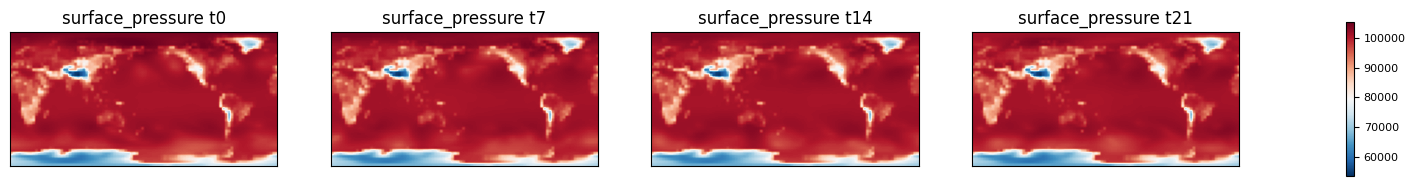

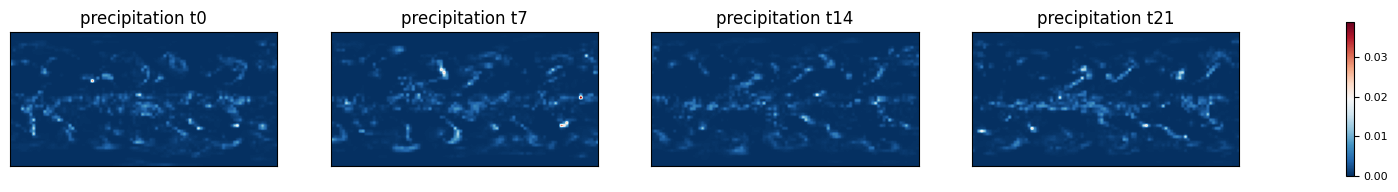

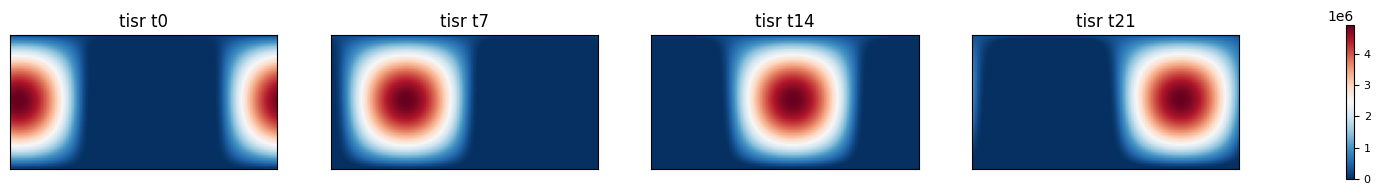

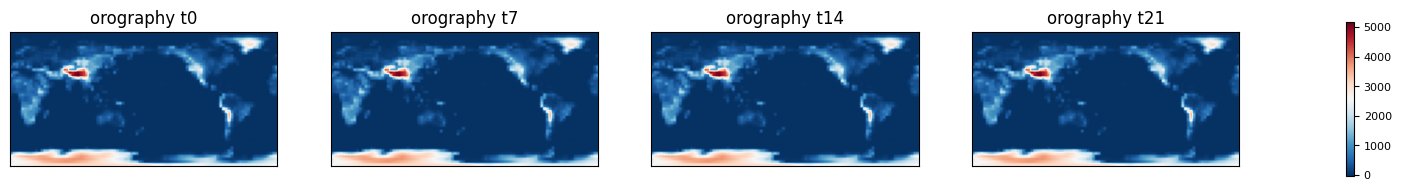

In [13]:
start_date = np.random.randint(0, data[keys].shape[0]-60)
print("starting date: year: %d"%(start_date//365+1980))
for keys in selected_keys:
    time_step = 7 # weekly interval
    total_steps = 4 # one month
    end_date = start_date + time_step * total_steps
    data_keys = data[keys][np.arange(start_date, end_date, time_step), :, :] # (total_steps, 48, 96)
    # print(data_keys.shape)
    
    # set vmax and vmin for each key
    vmax = data_keys.max()
    vmin = data_keys.min()      
    fig, axs = plt.subplots(1, total_steps+1, figsize=(20, 5))
    for i in range(total_steps):  
        axs[i].set_title(keys + ' t' + str(i*time_step))

        # the image is upside down ( the top should be the bottom   )
        # flip the image upside down
        im = axs[i].imshow(data_keys[i][::-1, :], cmap='RdBu_r', vmin=vmin, vmax=vmax) # blue to red colormap
        # add a line at the equator
        # axs[i].axhline(24, color='black', linestyle='--')
        axs[i].set_xticks([])
        axs[i].set_yticks([])
    
    # Add colorbar to the rightmost subplot
    ax_last = axs[-1]
    ax_last.axis('off')  # Hide the last subplot
    
    # Create a dummy image for the colorbar with the same vmin/vmax
    dummy_data = np.linspace(vmin, vmax, 100).reshape(10, 10)
    im_dummy = ax_last.imshow(dummy_data, vmin=vmin, vmax=vmax, cmap='RdBu_r')
    im_dummy.set_visible(False)  # Hide the dummy image
    
    # Add colorbar that matches the height of the data images
    cbar = plt.colorbar(im_dummy, ax=ax_last, fraction=0.8, shrink=0.4)
    cbar.ax.tick_params(labelsize=8)
        
    plt.show()

## 4. Long term temporal dynamic, aggregate data at a yearly interval

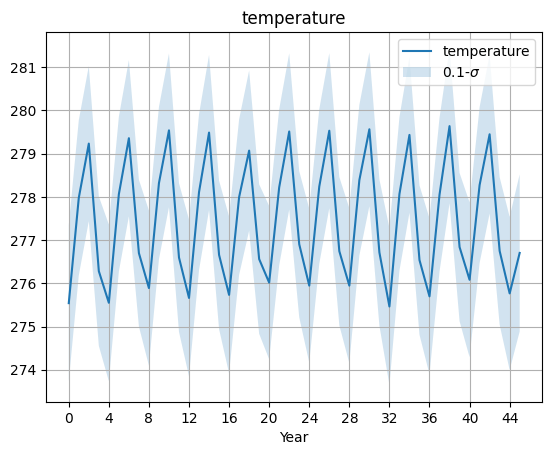

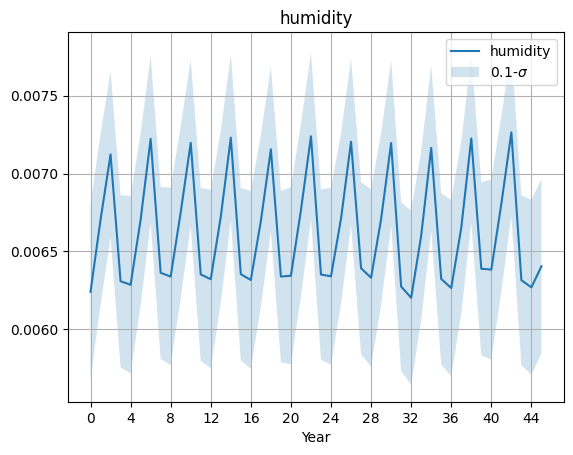

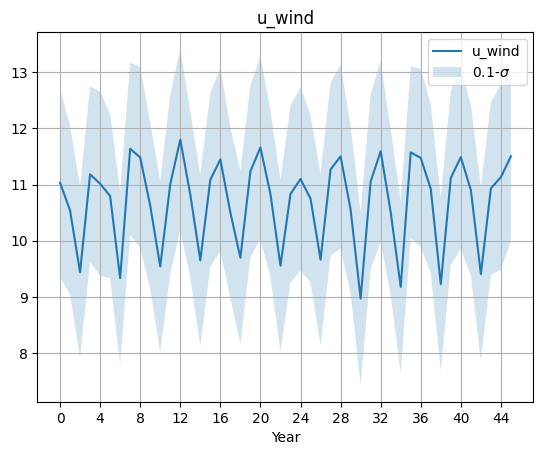

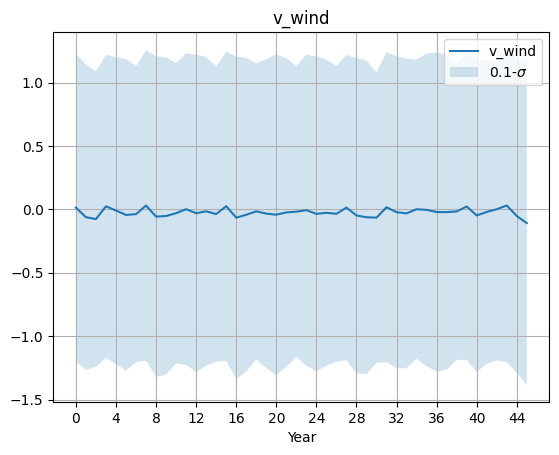

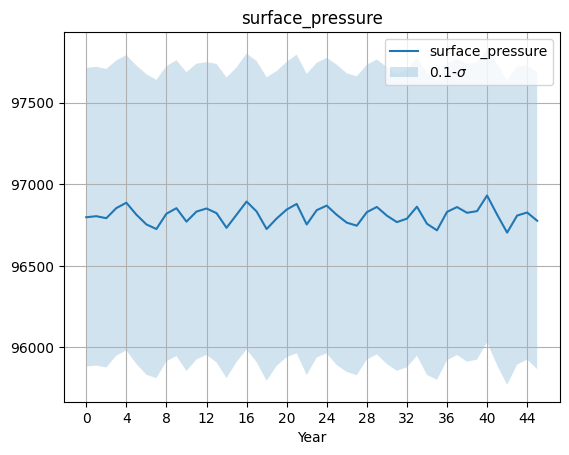

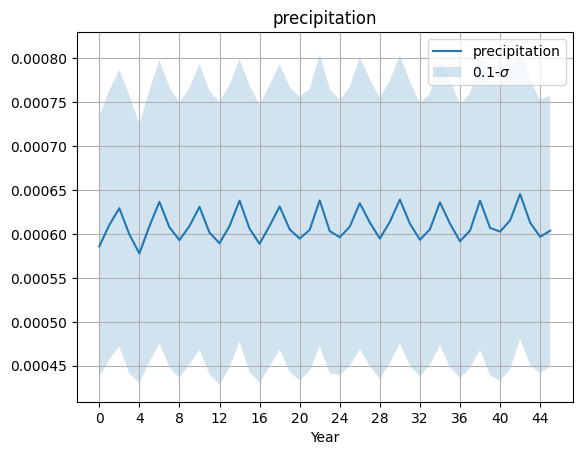

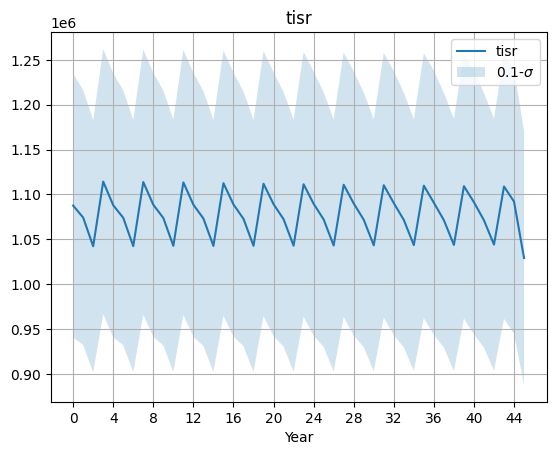

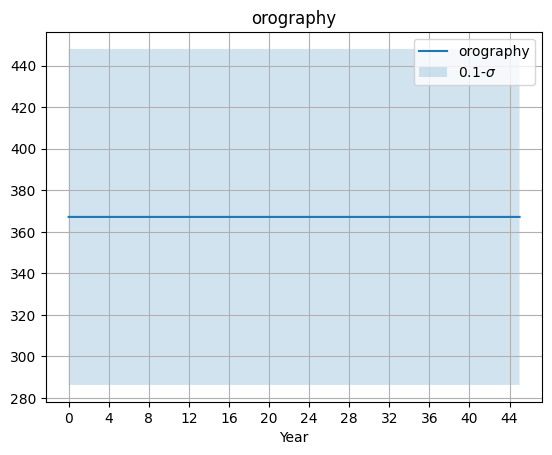

In [14]:
for keys in selected_keys:
    data_keys = data[keys] # (16538, 48, 96)
    step_size = 365
    # step_size = 28
    time_idx = np.arange(0, data_keys.shape[0], step_size)
    mean_list = []
    std_list = []
    # print(data_keys.shape)
    for i in range(time_idx.shape[0]):
        # print(i)
        # plot the mean and std of the data between time_idx[i] and time_idx[i+1]
        data_keys_i = data_keys[time_idx[i]:time_idx[i+1]] if i < time_idx.shape[0]-1 else data_keys[time_idx[i]:]
        data_keys_i_mean = data_keys_i.mean()
        data_keys_i_std = data_keys_i.std()
        # print(data_keys_i_mean)
        mean_list.append(data_keys_i_mean)
        std_list.append(data_keys_i_std)
    mean_list = np.array(mean_list)
    std_list = np.array(std_list)
    plt.plot(time_idx//step_size, mean_list, label=keys)
    plt.fill_between(time_idx//step_size, mean_list - 0.1*std_list, mean_list + 0.1*std_list, alpha=0.2, label='0.1-$\sigma$')
    # add more ticks in the x axis
    plt.xticks(np.arange(0, time_idx[-1]//step_size, 4))
    plt.title(keys)
    plt.xlabel('Year')
    plt.legend(loc='upper right')
    plt.grid('on')
    plt.show()

- looks like the seasonality is roughly 4 years?

## 5. run fft on the data, plot the power spectrum

In [15]:
def compute_energy(x, N):
    """
    compute_energy(x, N)
    Args:
        x: the input sequence, shape (N)
        N: the number of time steps
    Returns:
        frequencies_per_year: the frequencies in cycles per year
        power_spectrum: the power spectrum (amplitude squared)
    """
    # Remove mean to focus on variations
    x_detrended = x - np.mean(x)
    
    # Compute the Fourier transform
    fourier_transform = np.fft.fft(x_detrended)
    
    # Compute power spectrum (amplitude squared)
    power_spectrum = np.abs(fourier_transform)**2
    
    # Get frequencies (in cycles per day)
    frequencies_per_day = np.fft.fftfreq(N)
    
    # Convert to frequencies per year
    frequencies_per_year = frequencies_per_day * 365.25
    
    return frequencies_per_year, power_spectrum

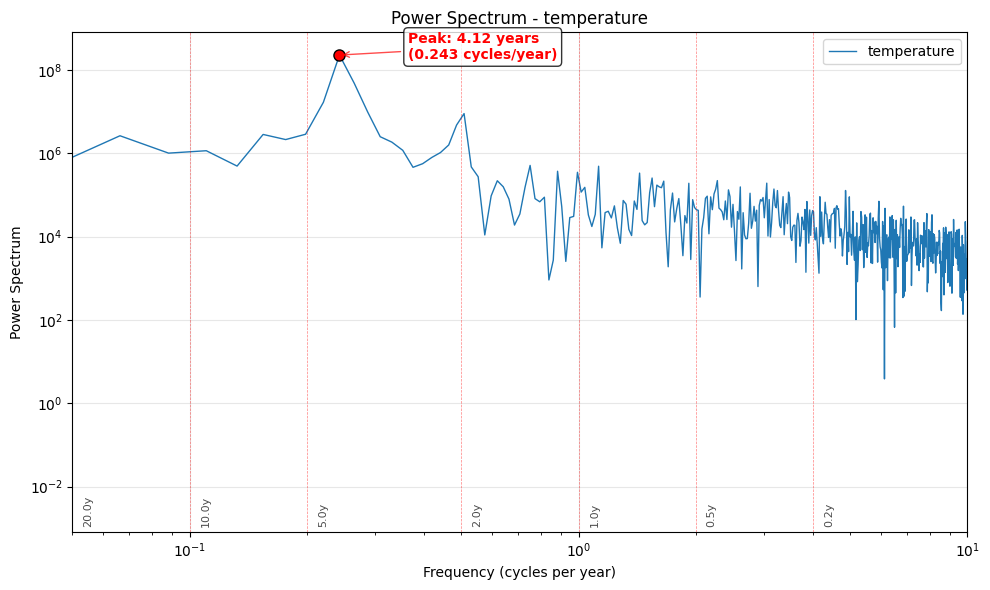

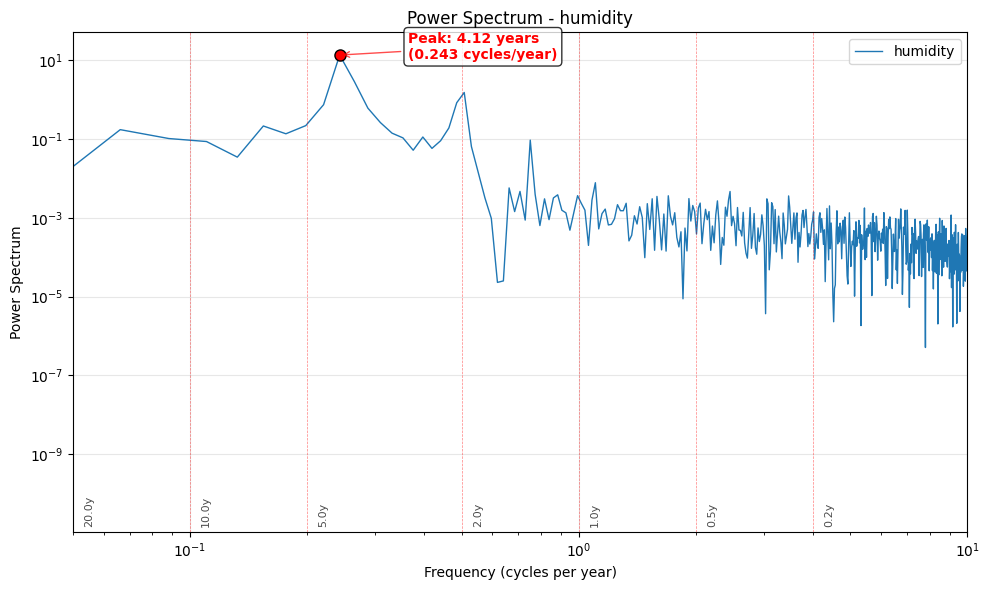

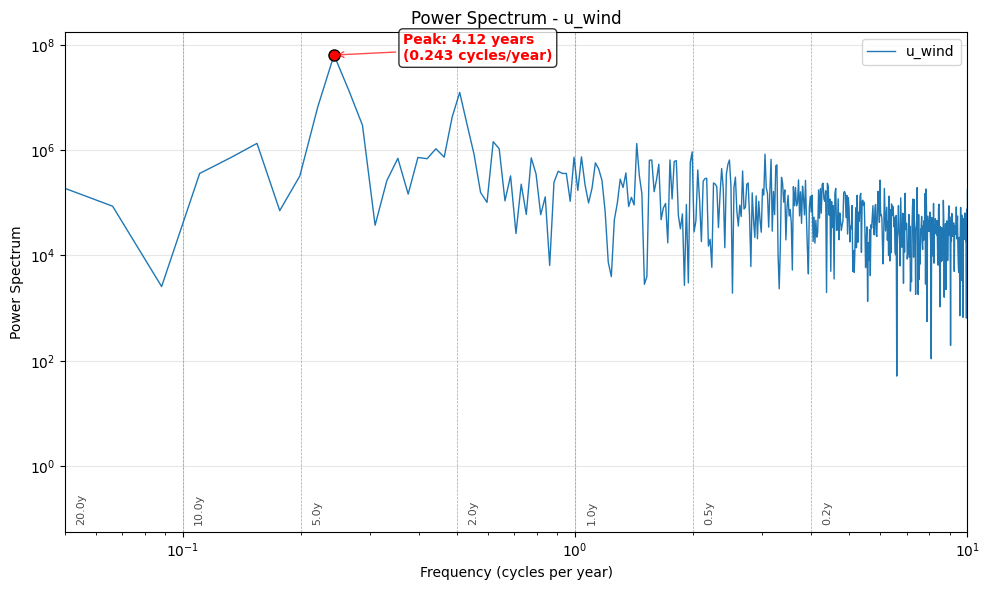

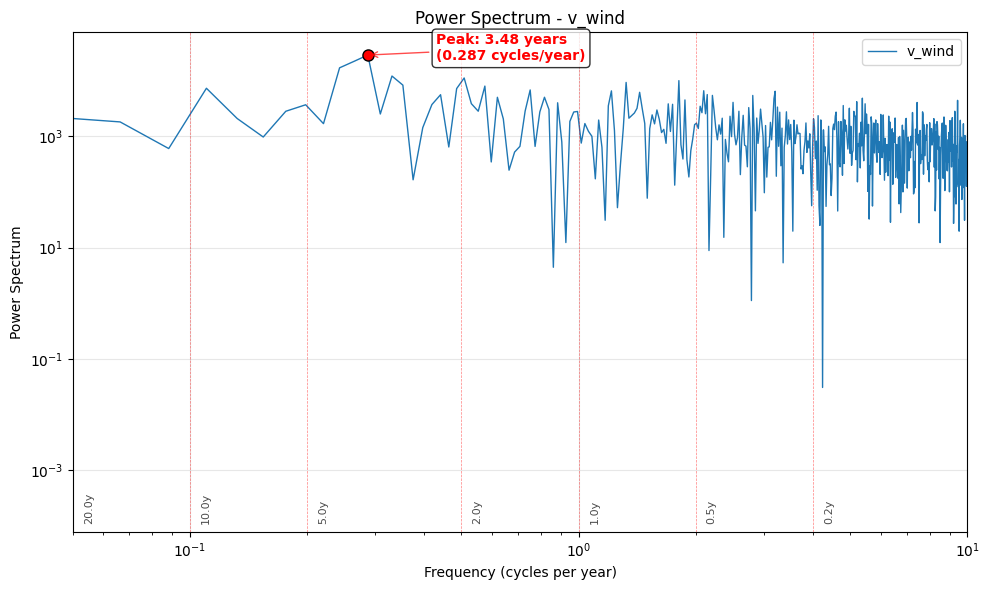

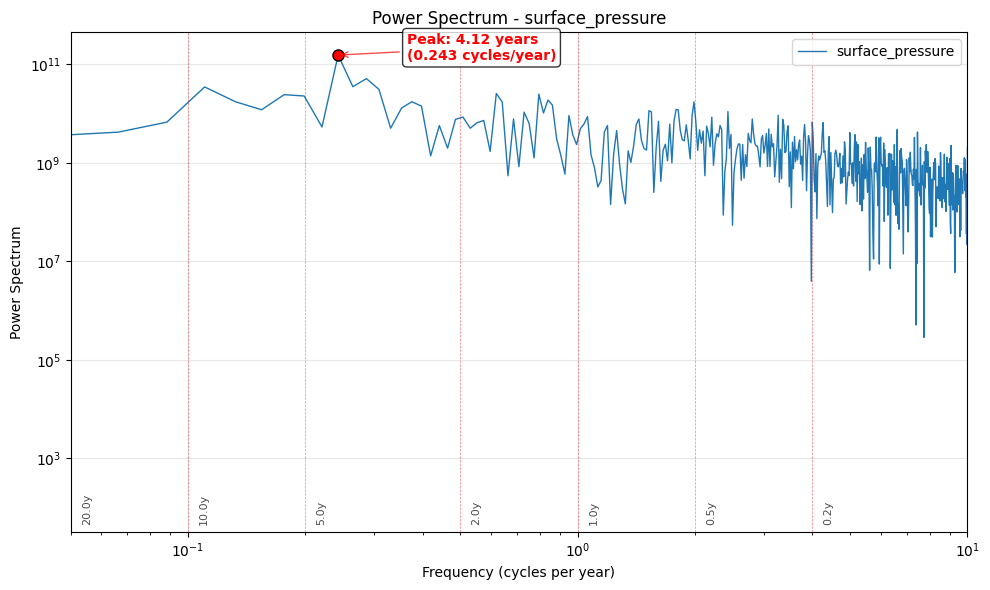

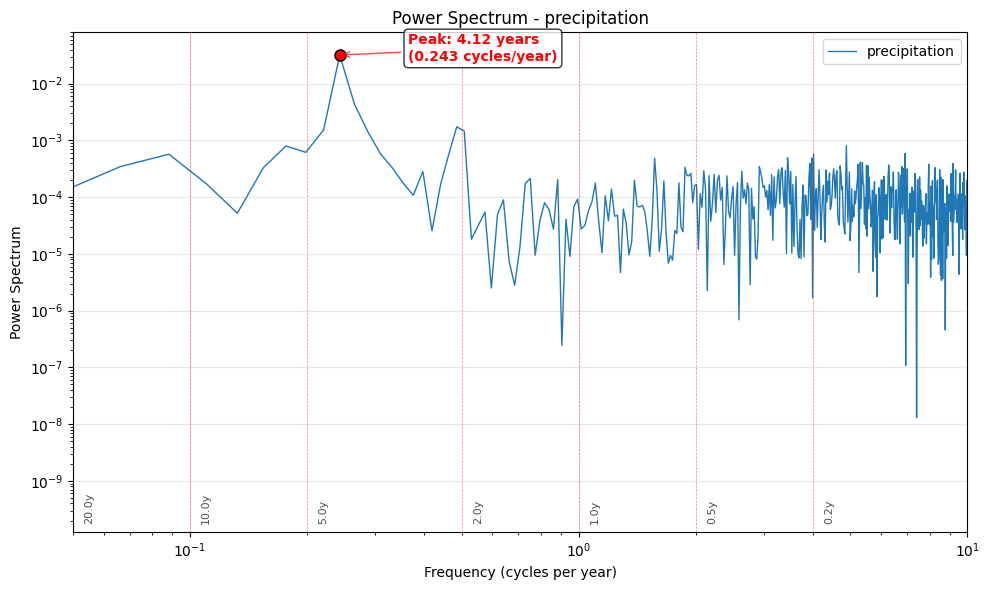

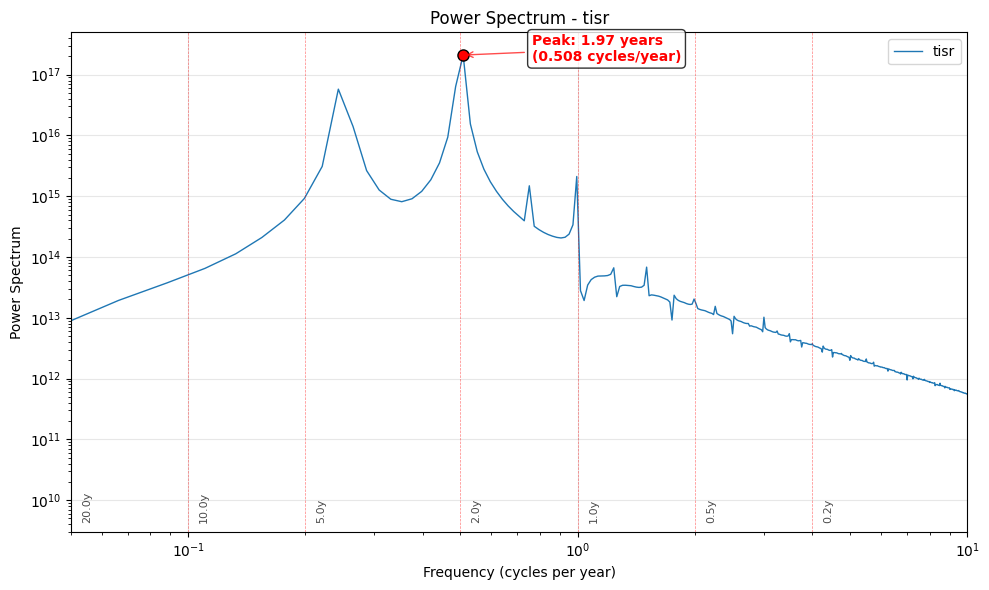

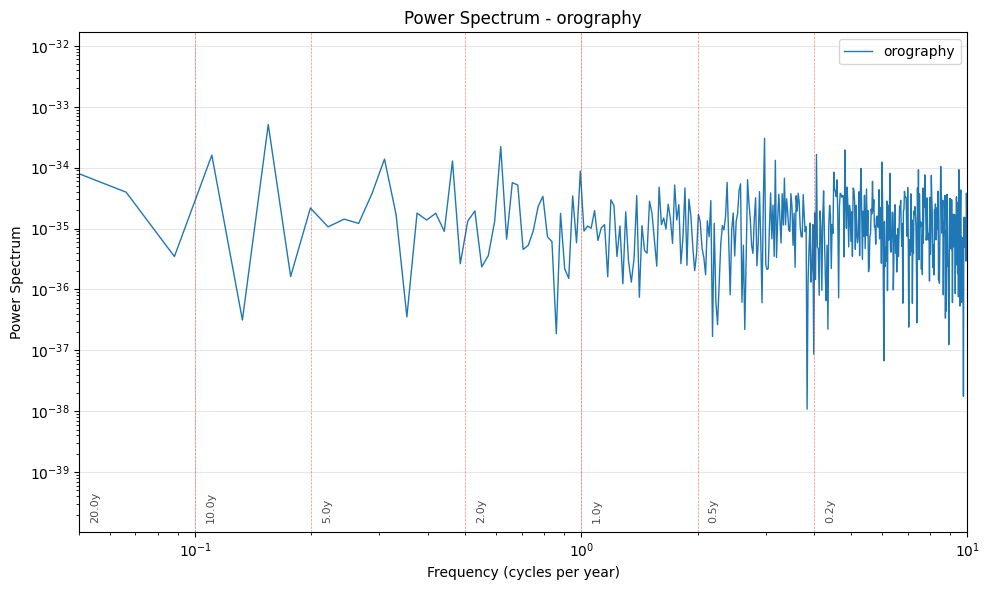

In [16]:
for keys in selected_keys:
    fig, axs = plt.subplots(1, 1, figsize=(10, 6))
    data_keys = data[keys] # (16538, 48, 96)
    data_keys_mean = data_keys.mean(axis=(1,2))
    
    # run fft on the data
    frequencies_per_year, power_spectrum = compute_energy(data_keys_mean, data_keys_mean.shape[0])
    
    # Filter out DC component (freq = 0) and negative frequencies
    valid_mask = (frequencies_per_year > 0) & (frequencies_per_year < 100)  # up to 100 cycles per year
    frequencies_filtered = frequencies_per_year[valid_mask]
    power_filtered = power_spectrum[valid_mask]
    
    # Sort by frequency for better visualization
    sort_idx = np.argsort(frequencies_filtered)
    frequencies_sorted = frequencies_filtered[sort_idx]
    power_sorted = power_filtered[sort_idx]
    
    # Plot the power spectrum
    axs.loglog(frequencies_sorted, power_sorted, label=keys, linewidth=1)
    
    # Find and highlight the highest power peak
    max_power_idx = np.argmax(power_sorted)
    max_freq = frequencies_sorted[max_power_idx]
    max_power = power_sorted[max_power_idx]
    max_period = 1/max_freq
    
    # Highlight the peak with a red dot and annotation
    axs.plot(max_freq, max_power, 'ro', markersize=8, markeredgecolor='black', markeredgewidth=1)
    axs.annotate(f'Peak: {max_period:.2f} years\n({max_freq:.3f} cycles/year)', 
                xy=(max_freq, max_power), xytext=(max_freq*1.5, max_power*0.8),
                arrowprops=dict(arrowstyle='->', color='red', alpha=0.7),
                fontsize=10, color='red', weight='bold',
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
    
    # Add vertical lines for common frequencies (convert periods to frequencies)
    common_periods_years = [0.25, 0.5, 1, 2, 5, 10, 20]  # years
    common_frequencies = [1/period for period in common_periods_years]  # cycles per year
    
    for freq in common_frequencies:
        if freq < frequencies_sorted.max():
            axs.axvline(freq, color='red', linestyle='--', alpha=0.5, linewidth=0.5)
            period = 1/freq
            axs.text(freq*1.1, axs.get_ylim()[0]*1.5, f'{period:.1f}y', 
                    rotation=90, fontsize=8, alpha=0.7, ha='center')
    
    axs.set_xlabel('Frequency (cycles per year)')
    axs.set_ylabel('Power Spectrum') 
    axs.set_title(f'Power Spectrum - {keys}')
    axs.grid(True, alpha=0.3)   
    axs.legend()
    
    # Set reasonable x-axis limits
    axs.set_xlim(0.05, 10)  # from 0.05 to 10 cycles per year (20 years to 0.1 years)
    
    plt.tight_layout()
    plt.show()

 # training setup

In [2]:
DATASET_DICT = {}
name = 'era5_48'
DATASET_DICT[name] = {}
DATASET_DICT[name]['train_size'] = 3650 # 10 years of data for training
DATASET_DICT[name]['val_size'] = 365*5 # 1 year of data for validation
DATASET_DICT[name]['test_size'] = 16538 - 3650 - 365*5 # 13188 years of data for testing
DATASET_DICT[name]['scatter_storage'] = False
DATASET_DICT[name]['t_out'] = 60   ## predict 60 timesteps for testing
DATASET_DICT[name]['t_in'] = 7    ## look back 7 days
DATASET_DICT[name]['t_total'] = 67
DATASET_DICT[name]['in_size'] = (48, 96)
DATASET_DICT[name]['channels_in'] = ['temperature', 'humidity', 'u_wind', 'v_wind', 'surface_pressure', 'tisr', 'orography']
DATASET_DICT[name]['channels_out'] = ['temperature', 'humidity', 'u_wind', 'v_wind', 'surface_pressure', 'tisr', 'orography', 'precipitation'] # precipitation is output channel only (diagnostic variable)
DATASET_DICT[name]['downsample'] = (1, 1)